<a href="https://colab.research.google.com/github/probson1981/CarbonLedger/blob/main/Atividade1_VC_Patricio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Processamento Digital de Imagens — Atividade 1**
## Aluno: Patrício Alves


## Classe A: Mouse
## Classe B: HD Externo

Importação das bibliotecas

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import drive
from pathlib import Path

## Upload das imagens

Enviar:
- 5 imagens da classe Mouse
- 5 imagens da classe HD Externo

## Aquisição das imagens

As imagens foram capturadas diretamente com a câmera de um smartphone **Realme C55**, sem utilização de imagens provenientes da internet. Foram realizadas variações controladas de distância, ângulo e iluminação, com o objetivo de representar diferentes condições de aquisição das duas classes definidas para o mini dataset: **Mouse** e **HD externo**.

| Arquivo | Classe | Iluminação | Ângulo | Distância aproximada | Ruído/desfoque | Observação |
|---|---|---|---|---|---|---|
| `img001_original.jpg` | Mouse | Natural | Superior, ~90° | ~40 cm | Não perceptível | Objeto inteiro, fundo neutro |
| `img002_original.jpg` | Mouse | Natural | Oblíquo, ~45° | ~40–50 cm | Não perceptível | Evidencia melhor o volume e a lateral do objeto |
| `img003_original.jpg` | Mouse | Natural | Superior, ~90° | ~20 cm | Não perceptível | Captura próxima, com maior detalhamento superficial |
| `img004_original.jpg` | Mouse | Natural | Superior, ~90° | ~70 cm | Não perceptível | Menor ocupação do objeto no quadro e maior presença do fundo |
| `img005_original.jpg` | Mouse | Artificial | Oblíquo, ~45° | ~40 cm | Não perceptível | Captura noturna com iluminação artificial; presença de reflexão luminosa na superfície da mesa |
| `img006_original.jpg` | HD externo | Natural | Superior, ~90° | ~40 cm | Não perceptível | Textura e forma do objeto bem visíveis |
| `img007_original.jpg` | HD externo | Natural | Oblíquo, ~40–45° | ~40 cm | Não perceptível | Evidencia espessura, lateral e conector do dispositivo |
| `img008_original.jpg` | HD externo | Natural | Superior, ~90° | ~20 cm | Não perceptível | Captura próxima, com textura superficial mais evidente |
| `img009_original.jpg` | HD externo | Natural | Superior, ~90° | ~70 cm | Não perceptível | Objeto ocupa pequena parte do quadro |
| `img010_original.jpg` | HD externo | Artificial | Oblíquo, ~45° | ~40 cm | Não perceptível | Captura noturna com iluminação artificial; bom contraste entre o objeto vermelho e o fundo |

### Observação sobre a aquisição

Durante a captura, a câmera estava configurada para inserir data e hora diretamente nas imagens. Essa informação passa a fazer parte dos pixels da imagem e pode ser considerada uma característica espúria, pois não pertence ao objeto de interesse. Em aplicações reais de Visão Computacional e Aprendizado de Máquina, esse tipo de informação deve ser evitado, pois pode introduzir correlações indesejadas no dataset.

Também foi possível observar que as condições de iluminação influenciaram diretamente a aparência dos objetos. Nas imagens obtidas com luz artificial, houve maior contraste e presença de reflexões na superfície da mesa e dos próprios objetos, enquanto as imagens realizadas com luz natural apresentaram iluminação mais difusa. Essas diferenças exemplificam como as condições de aquisição podem alterar a distribuição de intensidades e cores de uma imagem, mesmo quando o objeto fotografado permanece o mesmo.

# Criação das pastas
Classe Mouse e Classe HD

## Estrutura do mini dataset

O mini dataset foi organizado em duas classes, seguindo uma estrutura de diretórios semelhante à utilizada em projetos de Aprendizado de Máquina e Visão Computacional.

A hierarquia utilizada é:

```text
dataset/
├── mouse/
│   ├── img001_original.jpg
│   ├── img002_original.jpg
│   ├── img003_original.jpg
│   ├── img004_original.jpg
│   └── img005_original.jpg
│
└── hd_externo/
    ├── img006_original.jpg
    ├── img007_original.jpg
    ├── img008_original.jpg
    ├── img009_original.jpg
    └── img010_original.jpg


Carregar as imagens do .rar nas pastas que serão criadas abaixo.

In [5]:
os.makedirs("/content/dataset/mouse", exist_ok=True)
os.makedirs("/content/dataset/hd_externo", exist_ok=True)

print("Pastas criadas.")

Pastas criadas.


# Checando as Imagens Carregadas

In [22]:
dataset_dir = "/content/dataset"
mouse_dir = os.path.join(dataset_dir, "mouse")
hd_dir = os.path.join(dataset_dir, "hd_externo")

print("Estrutura encontrada:")
print("Mouse:", os.path.exists(mouse_dir))
print("HD externo:", os.path.exists(hd_dir))

print("\nArquivos da classe Mouse:")
for arquivo in sorted(os.listdir(mouse_dir)):
    print(" -", arquivo)

print("\nArquivos da classe HD externo:")
for arquivo in sorted(os.listdir(hd_dir)):
    print(" -", arquivo)

Estrutura encontrada:
Mouse: True
HD externo: True

Arquivos da classe Mouse:
 - img001_original.jpg
 - img002_original.jpg
 - img003_original.jpg
 - img004_original.jpg
 - img005_original.jpg

Arquivos da classe HD externo:
 - .ipynb_checkpoints
 - img006_original.jpg
 - img007_original.jpg
 - img008_original.jpg
 - img009_original.jpg
 - img010_original.jpg


## 3. Transformações de Imagens

### 3.1 Análise de Resolução

Para analisar o efeito da redução da resolução, foi selecionada uma imagem representativa de cada classe:

- **Classe Mouse:** `img003_original.jpg`
- **Classe HD externo:** `img006_original.jpg`

Para cada imagem foram geradas versões correspondentes a:

- resolução original;
- 50% da resolução original;
- 20% da resolução original.
- 10% da resolução original.

O objetivo é observar a perda de detalhes provocada pela redução do número de pixels e discutir seu possível impacto em aplicações de Visão Computacional.

### Análise da Classe Mouse

Classe Mouse: img003_original.jpg

Será plotada a imagem em reolução original, 50%, 20% e 10% respectivamente.

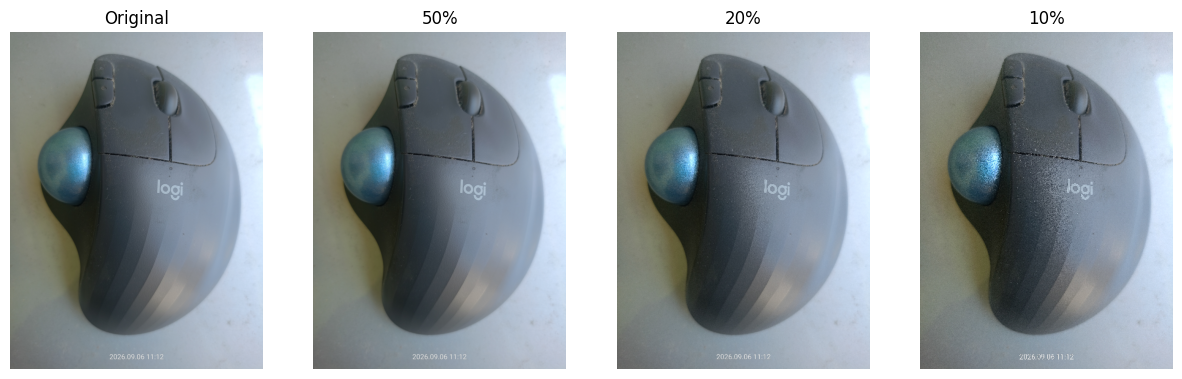

In [7]:
caminho_mouse = "/content/dataset/mouse/img003_original.jpg"
img = cv2.imread(caminho_mouse)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

altura, largura = img.shape[:2]

img_50 = cv2.resize(img, (largura//2, altura//2))
img_20 = cv2.resize(img, (largura//5, altura//5))
img_10 = cv2.resize(img, (largura//10, altura//10))

fig, ax = plt.subplots(1,4, figsize=(15,5))

ax[0].imshow(img)
ax[0].set_title("Original")

ax[1].imshow(img_50)
ax[1].set_title("50%")

ax[2].imshow(img_20)
ax[2].set_title("20%")

ax[3].imshow(img_10)
ax[3].set_title("10%")

for a in ax:
    a.axis('off')

plt.show()

#### Análise — Classe Mouse

A redução da resolução preservou a forma global do objeto nas versões de 50%, 20% e mesmo na de 10%, permitindo que o mouse continue visualmente reconhecível.

Entretanto, à medida que a resolução diminui (20% e 10%), ocorre perda progressiva de detalhes, na textura superficial, no logotipo e nos pequenos componentes do objeto.

Como na resolução de 20% era muito tênue essa perda de qualidade, optou-se por criar mais uma versão de resolução de 10% para se perceber mellhor a queda de qualidade.

Na versão de 50%, a perda visual é relativamente pequena para uma tarefa de classificação baseada na forma geral do objeto. Já na versão de 20% e 10%, a quantidade de informação espacial é significativamente reduzida, o que pode comprometer tarefas que dependam de detalhes pequenos, como reconhecimento de texto, inspeção de defeitos ou análise de textura.



### Análise da Classe HD Externo

Classe HD Externo: img00_original.jpg

Será plotada a imagem em reolução original, 50%, 20% e 10% respectivamente.

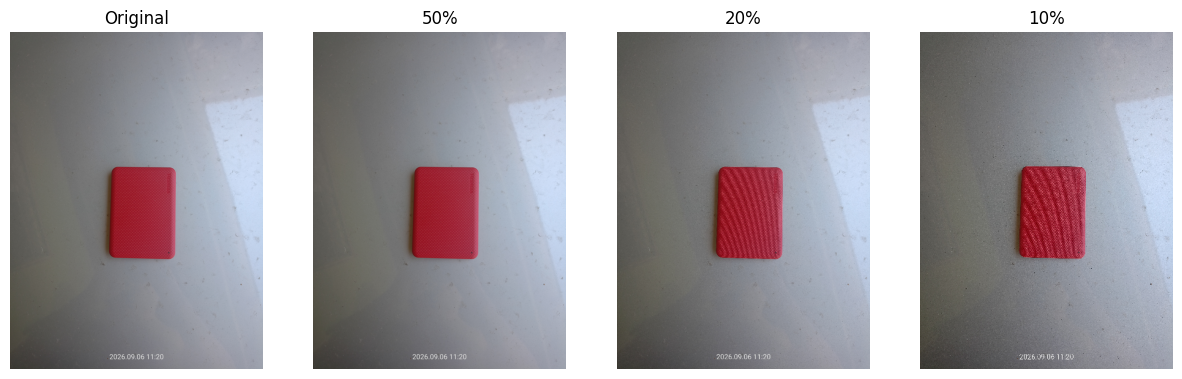

In [8]:
caminho_hd = "/content/dataset/hd_externo/img006_original.jpg"
img = cv2.imread(caminho_hd)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

altura, largura = img.shape[:2]

img_50 = cv2.resize(img, (largura//2, altura//2))
img_20 = cv2.resize(img, (largura//5, altura//5))
img_10 = cv2.resize(img, (largura//10, altura//10))

fig, ax = plt.subplots(1,4, figsize=(15,5))

ax[0].imshow(img)
ax[0].set_title("Original")

ax[1].imshow(img_50)
ax[1].set_title("50%")

ax[2].imshow(img_20)
ax[2].set_title("20%")

ax[3].imshow(img_10)
ax[3].set_title("10%")

for a in ax:
    a.axis('off')

plt.show()

#### Análise — Classe HD externo

A redução da resolução preservou a forma global e a cor predominante do HD externo, permitindo que o objeto continue facilmente reconhecível mesmo nas versões reduzidas.

Na resolução de 50%, a aparência geral permanece bastante próxima da imagem original, embora já haja redução da quantidade de informação espacial disponível.

Na versão de 20%, ocorre perda mais evidente de detalhes finos da superfície. A textura  presente no HD passa a apresentar padrões visuais mais marcados, decorrentes da redução direta da resolução.

Como análise adicional, foi gerada uma versão com 10% da resolução original em que se observa de forma mais marcante a perda de informação com uma mais visível degradação da textuda do HD.



#### Comentário

À medida que a resolução é reduzida detalhes e informação da imagem são perdidas podendo prejudicar tarefas de visão computacional como:
- reconhecimento de objetos
- segmentação
- extração de bordas
- classificação automática

### 3.2 Espaços de Cor

Nesta etapa, uma imagem representativa de cada classe foi analisada em diferentes representações de cor:

- **RGB**
- **HSV**
- **Escala de cinza**

Foram utilizadas as imagens:

- Classe Mouse: `img003_original.jpg`
- Classe HD externo: `img006_original.jpg`

O objetivo é observar como diferentes espaços de cor representam a mesma informação visual e discutir em quais tipos de aplicações cada representação pode ser mais adequada.

## Análise — Classe Mouse

### Análise dos canais de cor RGB

Nesta etapa, a imagem selecionada da classe **Mouse** é analisada no espaço de cor RGB (*Red, Green, Blue*).

Uma imagem RGB é formada pela combinação de três canais de intensidade:

- **R (Red)**: componente vermelha;
- **G (Green)**: componente verde;
- **B (Blue)**: componente azul.

Cada canal pode ser analisado separadamente como uma imagem em escala de cinza, na qual regiões mais claras representam maior intensidade daquele componente de cor e regiões mais escuras representam menor intensidade.

O objetivo desta análise é observar como diferentes características do objeto e do cenário são representadas individualmente em cada canal e verificar quais componentes apresentam maior contraste para determinados elementos da imagem.

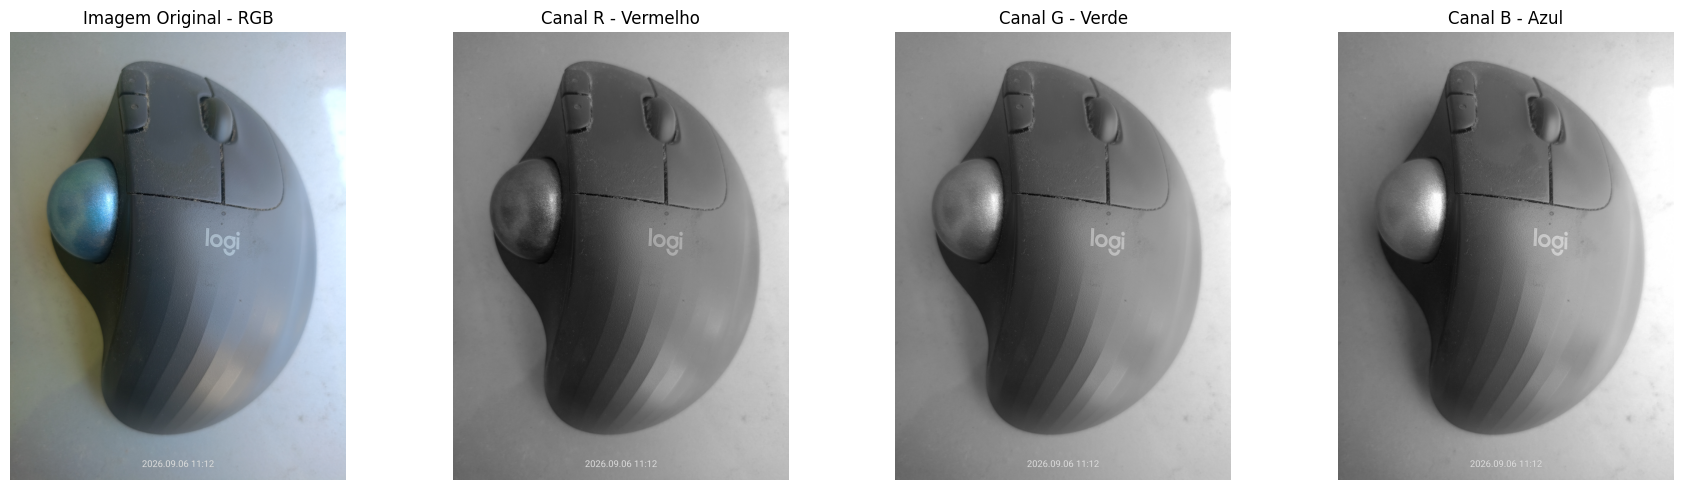

In [9]:
# Carregar a imagem
img_bgr = cv2.imread(caminho_mouse)

# OpenCV carrega em BGR -> converter para RGB
rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Separar os canais
R, G, B = cv2.split(rgb)

# Visualização
fig, ax = plt.subplots(1, 4, figsize=(18, 5))

ax[0].imshow(rgb)
ax[0].set_title("Imagem Original - RGB")

ax[1].imshow(R, cmap="gray")
ax[1].set_title("Canal R - Vermelho")

ax[2].imshow(G, cmap="gray")
ax[2].set_title("Canal G - Verde")

ax[3].imshow(B, cmap="gray")
ax[3].set_title("Canal B - Azul")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

#### Análise dos resultados — RGB

A decomposição da imagem nos canais R, G e B mostra que a aparência dos mesmos elementos varia conforme a contribuição de cada componente de cor.

O corpo do mouse, predominantemente cinza e de baixa saturação, apresenta aparência relativamente semelhante nos três canais, pois tons neutros tendem a possuir valores próximos nas componentes vermelha, verde e azul.

A esfera lateral do mouse apresenta comportamento diferente. Na imagem original ela possui tonalidade azulada, e por isso aparece com maior intensidade no **canal B**, ficando mais clara em comparação com o canal R. Essa diferença evidencia a maior participação da componente azul na formação de sua cor.

O fundo claro apresenta valores elevados nos três canais, aparecendo predominantemente claro em todas as representações. Entretanto, pequenas diferenças de iluminação e tonalidade fazem com que sua intensidade varie entre os canais.

Também é possível perceber que determinadas regiões, bordas e detalhes possuem contrastes diferentes dependendo do canal analisado. Isso demonstra que a separação dos canais RGB pode ser útil em tarefas nas quais uma determinada componente de cor favoreça a distinção entre objeto e fundo ou evidencie características específicas.

Em aplicações de Visão Computacional, a análise dos canais RGB pode ser utilizada, por exemplo, em segmentação baseada em cor, detecção de objetos com coloração característica, inspeção visual e extração de atributos cromáticos.

### Análise do espaço de cor HSV

Nesta etapa, a imagem selecionada da classe **Mouse** é convertida do espaço de cor RGB para o espaço HSV (*Hue, Saturation, Value*).

O espaço HSV representa as informações de cor de forma diferente do RGB, separando a informação cromática da intensidade luminosa:

- **H (Hue / Matiz):** representa a tonalidade ou tipo de cor;
- **S (Saturation / Saturação):** representa a intensidade ou pureza da cor;
- **V (Value / Valor):** representa o nível de brilho ou intensidade luminosa.

Essa separação pode facilitar determinadas tarefas de Visão Computacional, especialmente aquelas relacionadas à segmentação e identificação de regiões com base em características de cor.



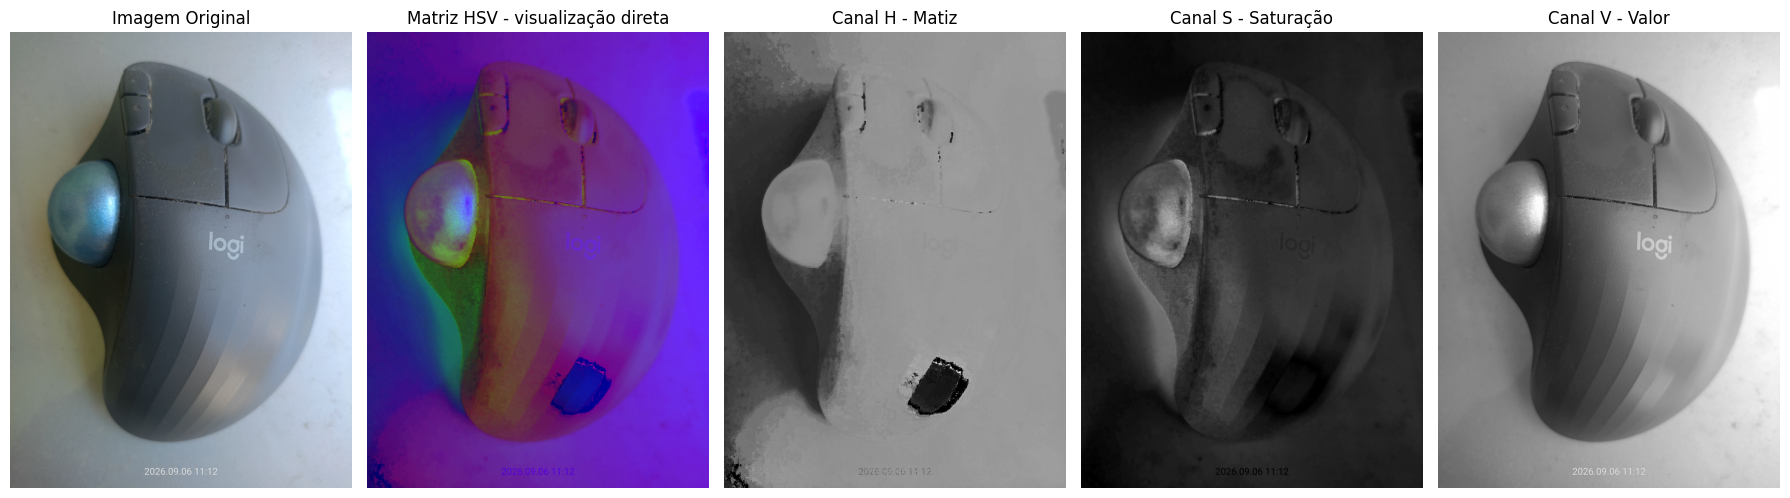

In [10]:
# Carregar a imagem
img_bgr = cv2.imread(caminho_mouse)

# Imagem RGB apenas para referência visual
rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converter BGR -> HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separar canais HSV
H, S, V = cv2.split(hsv)

# Visualização
fig, ax = plt.subplots(1, 5, figsize=(18, 5))

ax[0].imshow(rgb)
ax[0].set_title("Imagem Original")

ax[1].imshow(hsv)
ax[1].set_title("Matriz HSV - visualização direta")

ax[2].imshow(H, cmap="gray", vmin=0, vmax=179)
ax[2].set_title("Canal H - Matiz")

ax[3].imshow(S, cmap="gray", vmin=0, vmax=255)
ax[3].set_title("Canal S - Saturação")

ax[4].imshow(V, cmap="gray", vmin=0, vmax=255)
ax[4].set_title("Canal V - Valor")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

#### Análise dos resultados — HSV

A decomposição da imagem no espaço HSV evidencia características diferentes daquelas observadas diretamente no espaço RGB.

No **canal H (Matiz)**, as regiões são diferenciadas principalmente em função de sua tonalidade. A esfera lateral azulada do mouse apresenta comportamento distinto em relação ao corpo predominantemente cinza e ao fundo, indicando que o canal de matiz pode ser útil para distinguir regiões com cores diferentes.

No **canal S (Saturação)**, observa-se maior destaque nas regiões que possuem cores mais intensas. A esfera lateral apresenta maior resposta devido à sua tonalidade azulada mais saturada, enquanto o corpo cinza do mouse possui valores relativamente baixos de saturação. Esse comportamento mostra que o canal S pode ser particularmente útil para separar regiões coloridas de regiões neutras ou pouco saturadas.

O **canal V (Valor)** apresenta principalmente a informação relacionada à intensidade luminosa. Sua aparência se aproxima de uma representação em tons de cinza, destacando diferenças de iluminação, sombras, contornos e relevo do objeto. Regiões mais iluminadas apresentam maior intensidade, enquanto regiões sombreadas aparecem mais escuras.

A análise mostra que o espaço HSV permite separar aspectos que no RGB aparecem combinados. Em aplicações de Visão Computacional, essa representação pode ser vantajosa em tarefas como **segmentação baseada em cor, detecção de objetos coloridos, rastreamento de regiões específicas e análise menos dependente da intensidade luminosa**, especialmente quando os canais H e S são utilizados de forma adequada.

No caso desta imagem, a esfera azulada do mouse demonstra claramente a utilidade do HSV, pois sua informação cromática fica mais evidente nos canais H e S do que no canal V.

### Comparação entre RGB, HSV e Escala de Cinza

Nesta etapa, a mesma imagem da classe **Mouse** é representada em três formas distintas:

- **RGB**, que preserva a informação original de cor por meio dos canais vermelho, verde e azul;
- **HSV**, que reorganiza a informação de cor em matiz, saturação e valor;
- **Escala de cinza**, que elimina a informação cromática e mantém apenas a intensidade luminosa.

O objetivo é comparar visualmente como a mesma cena é representada em diferentes espaços de cor e observar quais informações são preservadas, realçadas ou descartadas em cada caso.



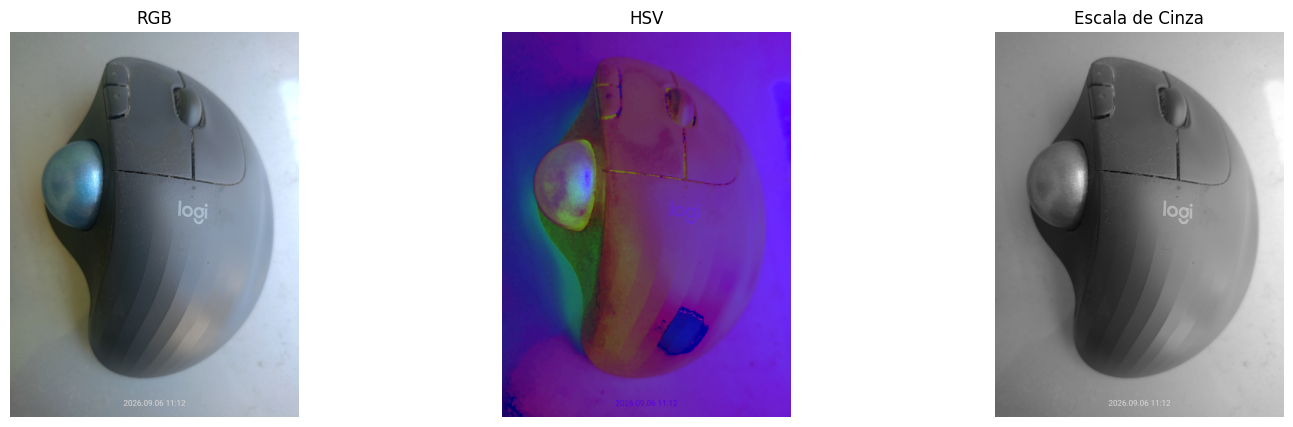

In [11]:
img_bgr = cv2.imread(caminho_mouse)

rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1,3, figsize=(18,5))

ax[0].imshow(rgb)
ax[0].set_title("RGB")

ax[1].imshow(hsv)
ax[1].set_title("HSV")

ax[2].imshow(gray, cmap='gray')
ax[2].set_title("Escala de Cinza")

for a in ax:
    a.axis('off')

plt.show()

#### Análise comparativa — RGB, HSV e Escala de Cinza

Na representação **RGB**, a imagem mantém sua aparência natural, preservando simultaneamente informações de cor, iluminação, forma e textura. A esfera lateral azulada do mouse, por exemplo, permanece claramente distinguível do corpo cinza do objeto.

A principal vantagem do HSV aparece quando seus canais são analisados separadamente. O canal H representa o matiz, o canal S representa a saturação e o canal V representa a intensidade luminosa, permitindo separar características cromáticas da iluminação.

Na visualização direta da matriz **HSV**, as cores exibidas destacam informações de tonalidade e brilho, facilitando a segmentação baseada em cor.


Na **escala de cinza**, toda a informação de cor é removida. Mesmo assim, a forma do mouse, suas bordas, botões, esfera lateral e diferenças de iluminação permanecem claramente perceptíveis. Isso demonstra que, para determinadas tarefas baseadas principalmente em forma, contorno ou textura, a informação cromática pode não ser indispensável.

Em aplicações de Visão Computacional, o **RGB** é adequado quando a cor é uma característica relevante; o **HSV** pode facilitar tarefas de segmentação e detecção baseadas em tonalidade e saturação; e a **escala de cinza** pode ser utilizada quando se deseja reduzir a quantidade de informação processada e a tarefa depende principalmente de intensidade, forma, textura ou contornos.

## Análise — Classe HD Externo

### Análise dos canais de cor RGB (Classe HD Externo)



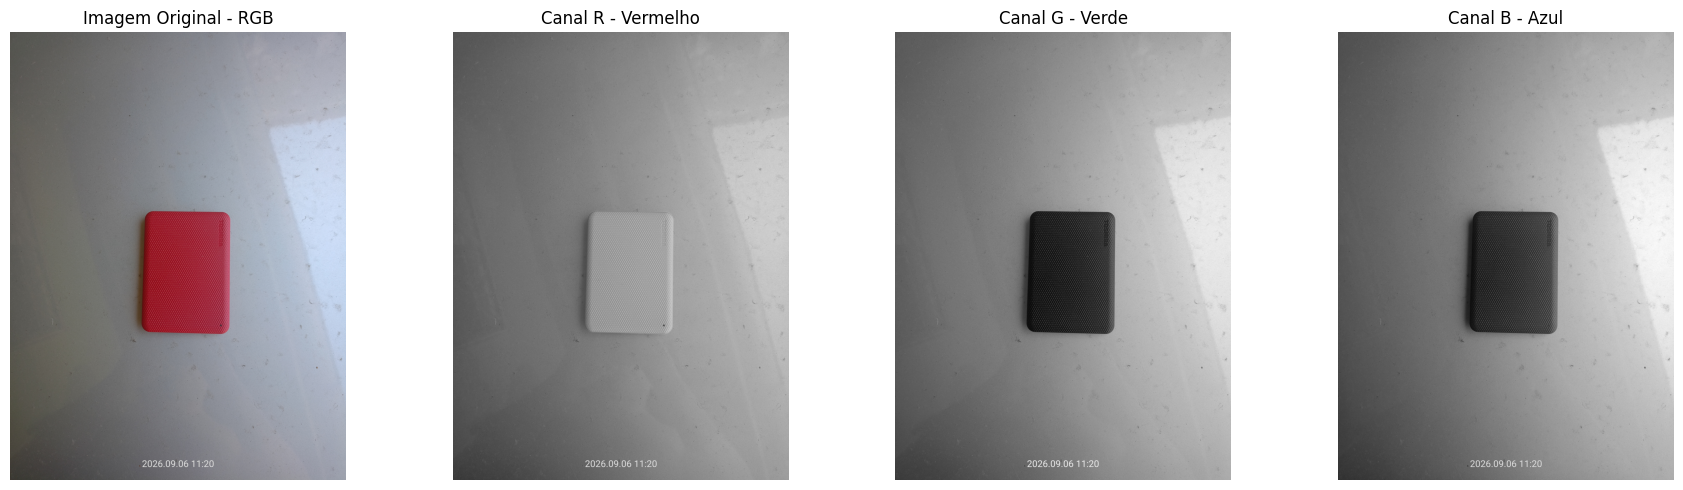

In [12]:
# Carregar a imagem
img_bgr = cv2.imread(caminho_hd)

# OpenCV carrega em BGR -> converter para RGB
rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Separar os canais
R, G, B = cv2.split(rgb)

# Visualização
fig, ax = plt.subplots(1, 4, figsize=(18, 5))

ax[0].imshow(rgb)
ax[0].set_title("Imagem Original - RGB")

ax[1].imshow(R, cmap="gray")
ax[1].set_title("Canal R - Vermelho")

ax[2].imshow(G, cmap="gray")
ax[2].set_title("Canal G - Verde")

ax[3].imshow(B, cmap="gray")
ax[3].set_title("Canal B - Azul")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

#### Análise dos resultados — RGB

A separação dos canais evidencia claramente a predominância da cor vermelha no HD externo.

No **canal R (Vermelho)**, o HD aparece muito claro, indicando valores elevados da componente vermelha nos pixels correspondentes ao objeto. Esse comportamento é coerente com sua aparência na imagem original, na qual o vermelho é a cor predominante.

Nos **canais G (Verde)** e **B (Azul)**, o mesmo objeto aparece significativamente mais escuro. Isso indica que as componentes verde e azul possuem intensidade relativamente baixa na formação da cor do HD.

Essa diferença entre os canais mostra como uma característica cromática específica pode produzir forte contraste em apenas uma das componentes RGB. Neste caso, o canal R permite uma separação bastante evidente entre o HD e parte do fundo.

O fundo claro apresenta valores relativamente elevados nos três canais, pois sua tonalidade é próxima de uma região neutra, formada por contribuições semelhantes das componentes R, G e B.

Esse resultado demonstra que, em aplicações de Visão Computacional nas quais o objeto de interesse possua uma cor dominante conhecida, a análise de um canal específico pode facilitar tarefas como **segmentação, localização de objetos e extração de características baseadas em cor**.

Neste exemplo, o **canal R é o mais informativo para destacar o HD externo**, enquanto os canais G e B apresentam menor resposta sobre o objeto.

### Análise do espaço de cor HSV (HD Externo)

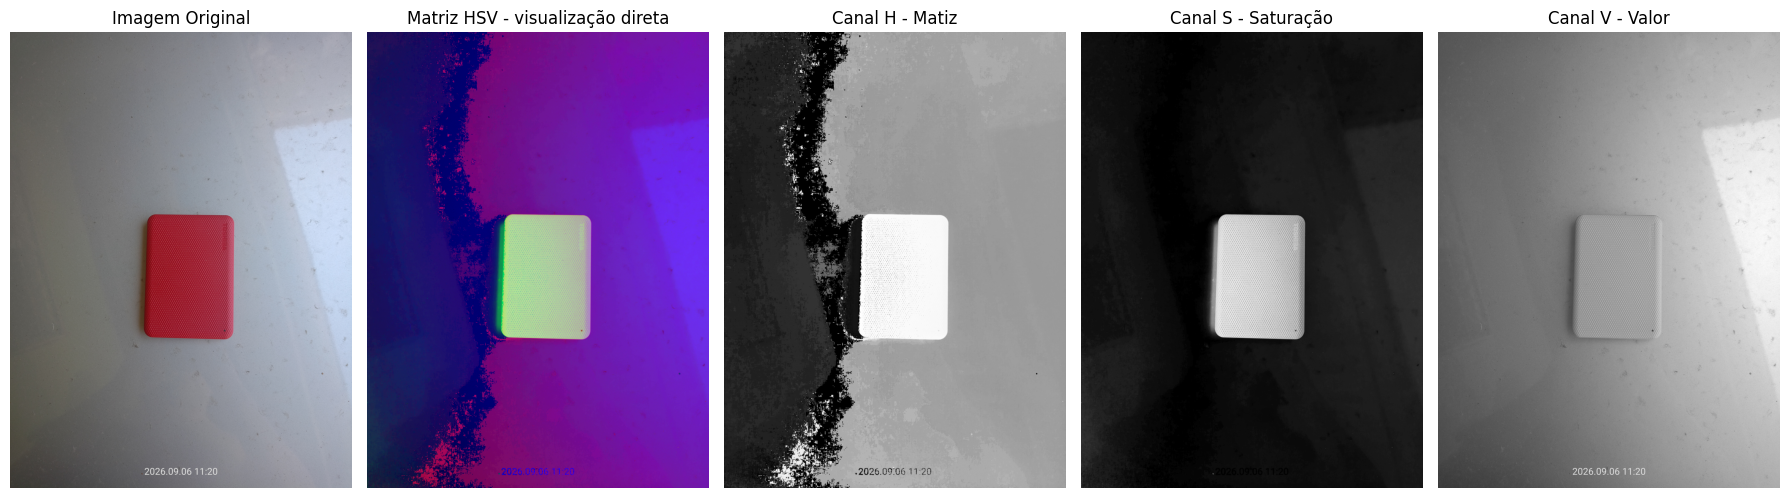

In [13]:
# Carregar a imagem
img_bgr = cv2.imread(caminho_hd)

# Imagem RGB apenas para referência visual
rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Converter BGR -> HSV
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Separar canais HSV
H, S, V = cv2.split(hsv)

# Visualização
fig, ax = plt.subplots(1, 5, figsize=(18, 5))

ax[0].imshow(rgb)
ax[0].set_title("Imagem Original")

ax[1].imshow(hsv)
ax[1].set_title("Matriz HSV - visualização direta")

ax[2].imshow(H, cmap="gray", vmin=0, vmax=179)
ax[2].set_title("Canal H - Matiz")

ax[3].imshow(S, cmap="gray", vmin=0, vmax=255)
ax[3].set_title("Canal S - Saturação")

ax[4].imshow(V, cmap="gray", vmin=0, vmax=255)
ax[4].set_title("Canal V - Valor")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

#### Análise dos resultados — HSV

A decomposição da imagem no espaço HSV evidencia de forma clara a diferença entre a informação de cor do HD externo e as características de iluminação da cena.

No **canal H (Matiz)**, o HD apresenta forte diferenciação em relação ao fundo. Como o objeto possui coloração predominantemente vermelha, seus pixels ocupam uma região específica do espaço de matiz. No OpenCV, o canal H é representado no intervalo de 0 a 179 e possui natureza circular; por isso, tonalidades próximas do vermelho podem aparecer próximas de uma das extremidades dessa faixa. Na imagem obtida, o HD apresenta elevada diferença de intensidade em relação ao fundo, tornando sua região facilmente identificável.

No **canal S (Saturação)**, a separação entre o HD e o fundo torna-se ainda mais evidente. O objeto vermelho apresenta elevada saturação e, por isso, aparece muito claro, enquanto grande parte do fundo, formado por tons mais neutros, apresenta baixa saturação e aparece mais escuro. Esse resultado demonstra que o canal S pode ser particularmente eficiente para distinguir o HD do cenário.

O **canal V (Valor)** representa principalmente a intensidade luminosa. Nesse canal, a informação específica da cor vermelha deixa de ser dominante e passam a ser mais evidentes os efeitos da iluminação da cena, como regiões claras, sombras e variações de brilho. Por esse motivo, sua aparência se aproxima de uma representação em tons de cinza.

A comparação mostra que o espaço HSV pode ser especialmente útil para a **segmentação do HD externo com base em sua cor**, pois os canais H e S permitem separar a característica cromática da influência direta da luminosidade. Em uma aplicação de Visão Computacional, seria possível definir intervalos de matiz e saturação para localizar automaticamente objetos vermelhos na imagem.

Neste caso, o **canal S apresenta uma separação visual particularmente forte entre o HD e o fundo**, enquanto o canal H fornece informação sobre a tonalidade e o canal V representa predominantemente as condições de iluminação.

### Comparação entre RGB, HSV e Escala de Cinza (HD Externo)

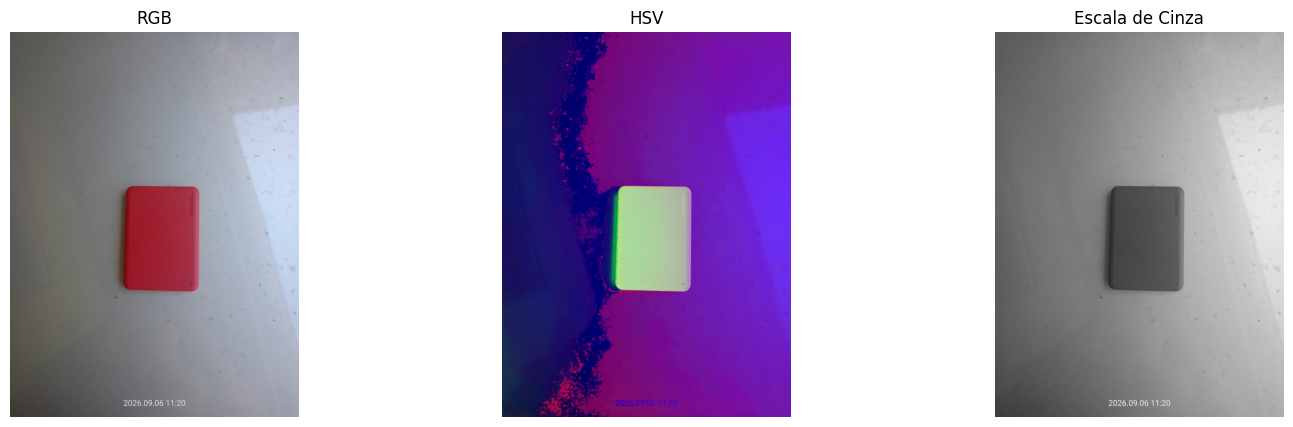

In [14]:
img_bgr = cv2.imread(caminho_hd)

rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, ax = plt.subplots(1,3, figsize=(18,5))

ax[0].imshow(rgb)
ax[0].set_title("RGB")

ax[1].imshow(hsv)
ax[1].set_title("HSV")

ax[2].imshow(gray, cmap='gray')
ax[2].set_title("Escala de Cinza")

for a in ax:
    a.axis('off')

plt.show()

#### Análise comparativa — RGB, HSV e Escala de Cinza

Na representação **RGB**, o HD externo apresenta claramente sua coloração vermelha, que constitui uma característica visual importante para sua diferenciação em relação ao fundo. Essa representação preserva simultaneamente informações de cor, forma, textura e iluminação.

A principal vantagem do HSV aparece quando seus canais são analisados separadamente. O canal H representa o matiz, o canal S representa a saturação e o canal V representa a intensidade luminosa, permitindo separar características cromáticas da iluminação.

Na visualização direta da matriz **HSV**, as cores exibidas destacam informações de tonalidade e brilho, facilitando a segmentação baseada em cor.

No caso do HD externo, a análise dos canais HSV mostrou que os canais **H e S** fornecem forte diferenciação entre o objeto vermelho e o fundo predominantemente neutro. Isso torna o HSV particularmente interessante para tarefas de segmentação e localização de objetos com uma determinada cor.

Na **escala de cinza**, a informação de cor vermelha é completamente eliminada. O HD continua reconhecível devido à sua forma, contorno, textura e diferença de intensidade em relação ao fundo, porém uma característica importante da classe — sua coloração — deixa de estar disponível.

Também é possível observar que o HD vermelho aparece relativamente escuro na imagem em escala de cinza. Isso ocorre porque a conversão para níveis de cinza considera a contribuição luminosa dos canais de cor, e não simplesmente a intensidade visual percebida da tonalidade original.

Para aplicações de Visão Computacional, o **RGB** é apropriado quando a informação cromática completa é relevante; o **HSV** pode ser vantajoso em segmentação e detecção baseadas em cor; e a **escala de cinza** pode ser adequada quando a tarefa depende principalmente de forma, bordas, textura ou intensidade luminosa e se deseja reduzir a quantidade de informação processada.

### 3.3 Quantização de níveis de cinza

Nesta etapa é analisado o efeito da **quantização**, isto é, da redução da quantidade de níveis de intensidade disponíveis para representar uma imagem em escala de cinza.

Foram utilizadas uma imagem representativa de cada classe:

- **Mouse:** `img003_original.jpg`
- **HD externo:** `img006_original.jpg`

Para cada imagem foram geradas versões com:

- **256 níveis de cinza** — equivalente a 8 bits;
- **64 níveis de cinza** — equivalente a 6 bits;
- **32 níveis de cinza** — equivalente a 5 bits;
- **2 níveis de cinza** — equivalente a 1 bit.

Quanto menor o número de níveis disponíveis, menor é a precisão utilizada para representar as variações de intensidade da imagem. O objetivo é observar como essa redução afeta detalhes, contraste, textura e reconhecimento visual dos objetos.

## Análise — Classe Mouse

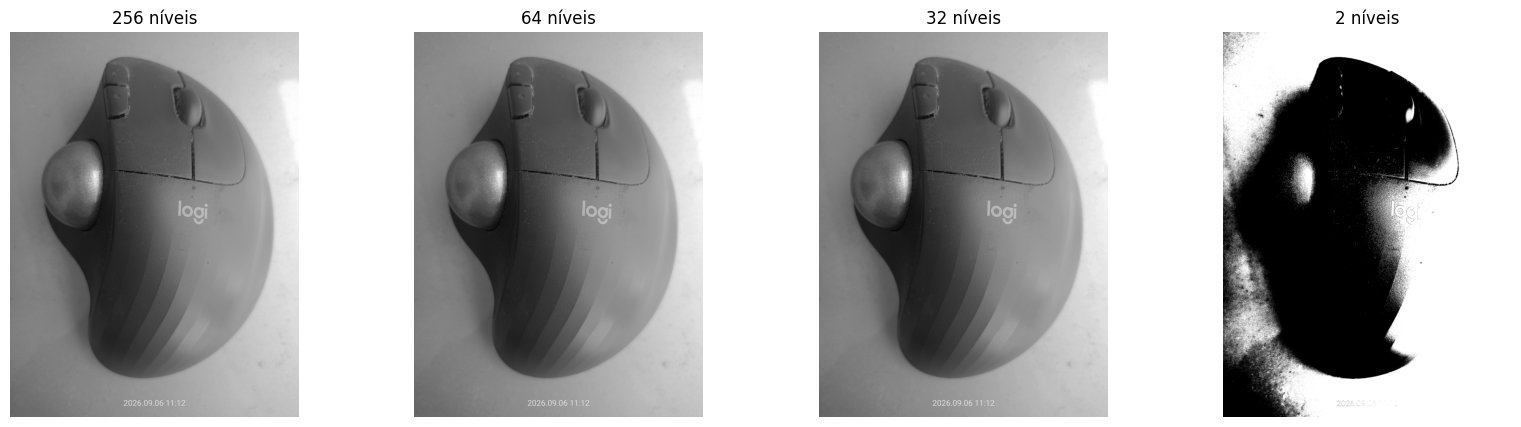

In [15]:
img = cv2.imread(caminho_mouse, 0)

q64 = (img // 4) * 4
q32 = (img // 8) * 8
q2 = ((img > 127) * 255).astype(np.uint8)

fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("256 níveis")

ax[1].imshow(q64, cmap='gray')
ax[1].set_title("64 níveis")

ax[2].imshow(q32, cmap='gray')
ax[2].set_title("32 níveis")

ax[3].imshow(q2, cmap='gray')
ax[3].set_title("2 níveis")

for a in ax:
    a.axis('off')

plt.show()

#### Análise dos resultados — Quantização do Mouse

Na imagem com **256 níveis de cinza**, observa-se uma representação tonal contínua, com boa preservação das variações de iluminação, sombras, textura e detalhes do mouse.

Com **64 níveis**, a diferença visual em relação à imagem de 256 níveis ainda é pequena. A forma do objeto, os botões, a esfera lateral, o logotipo e as variações de iluminação continuam claramente identificáveis. Isso indica que uma redução moderada da quantidade de níveis pode preservar grande parte da informação visual relevante.

Na versão com **32 níveis**, o objeto também permanece facilmente reconhecível. Entretanto, começa a ocorrer maior simplificação das transições tonais. Mesmo assim, os principais contornos e características estruturais continuam preservados.

A maior alteração ocorre na imagem com **2 níveis**, na qual cada pixel pode assumir apenas dois valores: preto ou branco. Nesse caso, ocorre uma forte perda de informação tonal. Regiões com diferentes níveis de cinza passam a ser agrupadas em apenas duas classes de intensidade, fazendo desaparecer grande parte das texturas, sombras e detalhes internos do mouse.

Apesar dessa perda, a forma global do objeto ainda pode ser parcialmente reconhecida na imagem binária. Entretanto, essa representação seria inadequada para aplicações que necessitem analisar textura, pequenas diferenças de intensidade ou detalhes superficiais.

Para este dataset, as versões com **64 ou 32 níveis** ainda preservam informações suficientes para uma tarefa simples de classificação entre Mouse e HD externo. A representação com **2 níveis** poderia ser útil em aplicações específicas, como análise de silhuetas, máscaras binárias, segmentação simples ou detecção de contornos, mas apresenta perda excessiva de informação para uma análise visual mais detalhada.

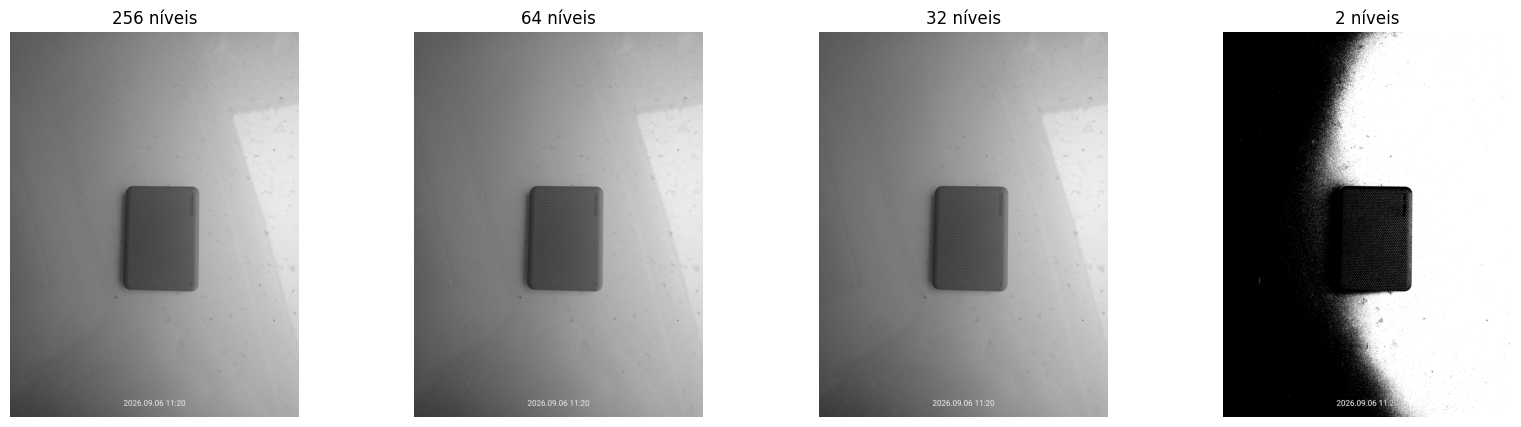

In [16]:
img = cv2.imread(caminho_hd, 0)

q64 = (img // 4) * 4
q32 = (img // 8) * 8
q2 = ((img > 127) * 255).astype(np.uint8)

fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("256 níveis")

ax[1].imshow(q64, cmap='gray')
ax[1].set_title("64 níveis")

ax[2].imshow(q32, cmap='gray')
ax[2].set_title("32 níveis")

ax[3].imshow(q2, cmap='gray')
ax[3].set_title("2 níveis")

for a in ax:
    a.axis('off')

plt.show()

#### Análise dos resultados — Quantização do HD externo

Na versão com **256 níveis de cinza**, a imagem apresenta transições tonais suaves e boa preservação das variações de iluminação do fundo, das sombras ao redor do objeto e dos detalhes superficiais do HD externo.

Com **64 níveis**, a aparência permanece muito próxima da versão original em escala de cinza. A forma retangular do HD, seus contornos e a diferença de intensidade em relação ao fundo continuam claramente perceptíveis.

Na imagem com **32 níveis**, ainda é possível reconhecer facilmente o objeto. Entretanto, ocorre maior simplificação das transições de intensidade. Mesmo assim, os principais atributos estruturais do HD permanecem preservados.

Na versão com **2 níveis**, a redução é muito mais severa. A imagem passa a conter apenas pixels pretos e brancos, eliminando praticamente todas as variações intermediárias de intensidade. Como consequência, grande parte da informação sobre textura, iluminação e detalhes superficiais é perdida.

Apesar dessa perda, a forma aproximadamente retangular do HD externo ainda permanece identificável, o que demonstra que determinadas características geométricas podem sobreviver mesmo a uma quantização extrema.

Para uma tarefa simples de classificação entre as classes **Mouse** e **HD externo**, as versões com **64 e 32 níveis** ainda mantêm informações visuais suficientes para distinguir os objetos. Já a versão com **2 níveis** apresenta perda excessiva de informação e seria mais apropriada para aplicações específicas, como obtenção de máscaras binárias, análise de silhuetas, segmentação ou detecção de contornos.

#### Comparação entre as classes

Os experimentos realizados com as classes Mouse e HD externo mostram que a redução moderada da quantidade de níveis de cinza, de 256 para 64 ou 32 níveis, provoca pouca perda perceptível das características globais dos objetos.

A quantização para apenas 2 níveis, entretanto, elimina grande parte das informações tonais e texturais. Mesmo assim, as formas gerais dos dois objetos ainda permanecem parcialmente distinguíveis: o mouse por seu formato curvo e o HD externo por sua geometria predominantemente retangular.

Dessa forma, a quantidade adequada de níveis de quantização depende da aplicação. Tarefas de classificação baseadas principalmente em forma podem tolerar reduções maiores, enquanto tarefas de inspeção superficial, análise de textura ou identificação de pequenos detalhes necessitam de maior profundidade tonal.

### 3.4 Comparação de formatos de arquivo — JPEG e PNG

Nesta etapa é analisado o impacto do formato de armazenamento sobre o tamanho e a qualidade das imagens.

Foram comparados dois formatos:

- **JPEG**, utilizando compressão com perdas;
- **PNG**, utilizando compressão sem perdas.

Para a comparação, uma imagem de cada classe foi salva novamente nos dois formatos e posteriormente foram avaliados:

- tamanho do arquivo em KB;
- diferença visual percebida;
- possível impacto do formato em tarefas de Processamento Digital de Imagens e Visão Computacional.

O JPEG tende a produzir arquivos menores por meio da eliminação de parte da informação visual, enquanto o PNG preserva exatamente os valores da imagem fornecida ao processo de salvamento.

## Análise — Classe Mouse

Tamanho original: 4187.96 KB
Tamanho JPEG: 545.38 KB
Tamanho PNG: 22426.50 KB


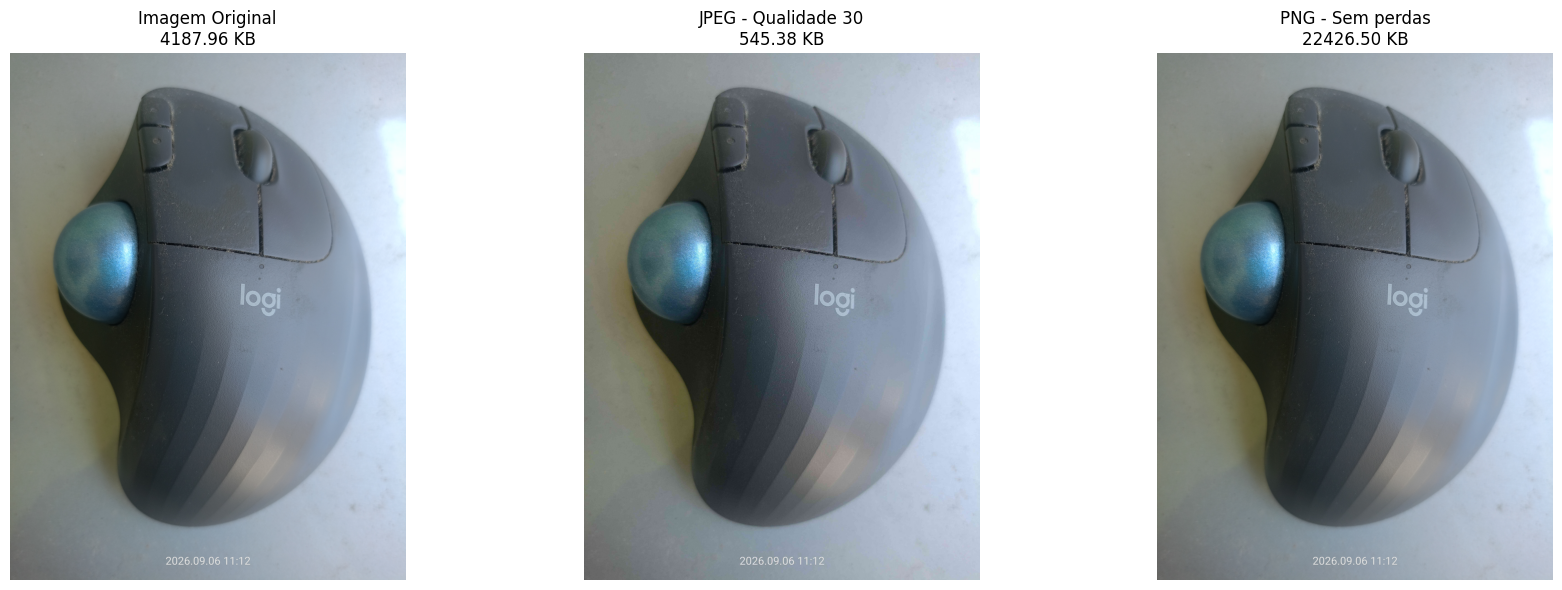

In [20]:
img = cv2.imread(caminho_mouse)

cv2.imwrite('mouse_compressao.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 30])
cv2.imwrite('mouse_sem_perda.png', img)

original_size = os.path.getsize(caminho_mouse) / 1024
jpg_size = os.path.getsize('mouse_compressao.jpg') / 1024
png_size = os.path.getsize('mouse_sem_perda.png') / 1024

print(f"Tamanho original: {original_size:.2f} KB")
print(f"Tamanho JPEG: {jpg_size:.2f} KB")
print(f"Tamanho PNG: {png_size:.2f} KB")

# ---------------------------------------------------------
# Carregar as três imagens para visualização
# ---------------------------------------------------------

img_original = cv2.imread(caminho_mouse)
img_jpg = cv2.imread('mouse_compressao.jpg')
img_png = cv2.imread('mouse_sem_perda.png')

# Converter BGR -> RGB para exibição no Matplotlib
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_jpg_rgb = cv2.cvtColor(img_jpg, cv2.COLOR_BGR2RGB)
img_png_rgb = cv2.cvtColor(img_png, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Visualização
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_original_rgb)
ax[0].set_title(
    f"Imagem Original\n{original_size:.2f} KB"
)

ax[1].imshow(img_jpg_rgb)
ax[1].set_title(
    f"JPEG - Qualidade 30\n{jpg_size:.2f} KB"
)

ax[2].imshow(img_png_rgb)
ax[2].set_title(
    f"PNG - Sem perdas\n{png_size:.2f} KB"
)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

#### Análise dos resultados — Formatos JPEG e PNG

A imagem original apresentou tamanho de **4187,96 KB**. Após ser novamente salva no formato JPEG com qualidade 30, seu tamanho foi reduzido para **545,38 KB**, correspondendo a uma redução de aproximadamente 87% em relação ao arquivo original.

A versão PNG apresentou tamanho de **22426,50 KB**, aproximadamente 5,4 vezes maior que a imagem original. Esse aumento ocorre porque o PNG utiliza compressão sem perdas e, em imagens fotográficas que apresentam grande quantidade de variações de cor, textura, iluminação e ruído, a redução de tamanho obtida por compressão sem perdas tende a ser muito menor do que aquela alcançada pelo JPEG.

Na comparação visual apresentada na escala utilizada, as três imagens permanecem muito semelhantes. A versão JPEG com qualidade 30 ainda preserva a forma, as cores e os principais detalhes do mouse, apesar da redução expressiva do tamanho do arquivo. Entretanto, a compressão JPEG descarta informações e pode introduzir artefatos que se tornam mais perceptíveis em ampliações, regiões com bordas, texturas ou detalhes finos.

A versão PNG preserva exatamente os valores dos pixels da imagem que foi fornecida ao processo de salvamento, não introduzindo novas perdas decorrentes da compressão. Entretanto, essa preservação resulta em um arquivo significativamente maior.

É importante observar que a fotografia original já foi capturada e armazenada pelo smartphone em formato JPEG. Portanto, salvar essa imagem posteriormente como PNG não recupera informações que eventualmente tenham sido perdidas durante a compressão realizada pela câmera. O PNG apenas evita a introdução de novas perdas a partir da imagem já decodificada.

Em tarefas de Processamento Digital de Imagens e Visão Computacional, o JPEG pode ser adequado quando o volume de armazenamento e a velocidade de transferência são importantes e pequenas perdas de informação são aceitáveis. O PNG pode ser mais apropriado quando é necessário preservar exatamente os valores dos pixels, como em imagens intermediárias de processamento, máscaras de segmentação, imagens sintéticas ou aplicações nas quais pequenas alterações nos dados possam afetar a análise.

## Análise — Classe HD Externo

Tamanho original: 4391.31 KB
Tamanho JPEG: 711.64 KB
Tamanho PNG: 23036.32 KB


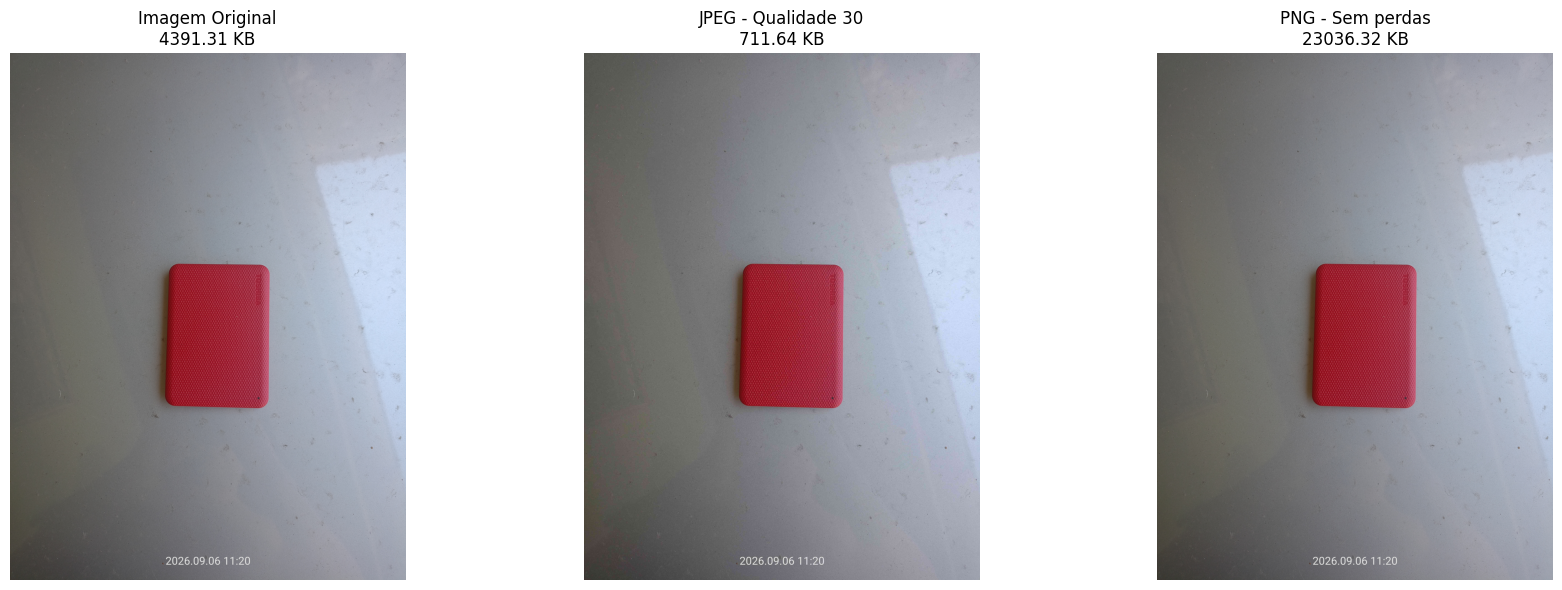

In [21]:
img = cv2.imread(caminho_hd)

cv2.imwrite('hd_compressao.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 30])
cv2.imwrite('hd_sem_perda.png', img)

original_size = os.path.getsize(caminho_hd) / 1024
jpg_size = os.path.getsize('hd_compressao.jpg') / 1024
png_size = os.path.getsize('hd_sem_perda.png') / 1024

print(f"Tamanho original: {original_size:.2f} KB")
print(f"Tamanho JPEG: {jpg_size:.2f} KB")
print(f"Tamanho PNG: {png_size:.2f} KB")

# ---------------------------------------------------------
# Carregar as três imagens para visualização
# ---------------------------------------------------------

img_original = cv2.imread(caminho_hd)
img_jpg = cv2.imread('hd_compressao.jpg')
img_png = cv2.imread('hd_sem_perda.png')

# Converter BGR -> RGB para exibição no Matplotlib
img_original_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_jpg_rgb = cv2.cvtColor(img_jpg, cv2.COLOR_BGR2RGB)
img_png_rgb = cv2.cvtColor(img_png, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Visualização
# ---------------------------------------------------------

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(img_original_rgb)
ax[0].set_title(
    f"Imagem Original\n{original_size:.2f} KB"
)

ax[1].imshow(img_jpg_rgb)
ax[1].set_title(
    f"JPEG - Qualidade 30\n{jpg_size:.2f} KB"
)

ax[2].imshow(img_png_rgb)
ax[2].set_title(
    f"PNG - Sem perdas\n{png_size:.2f} KB"
)

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

#### Análise dos resultados — Formatos JPEG e PNG

A imagem original do HD externo apresentou tamanho de **4391,31 KB**. Após ser salva novamente em JPEG com qualidade 30, o tamanho foi reduzido para **711,64 KB**, correspondendo a uma redução aproximada de **83,8%** em relação ao arquivo original.

A versão PNG apresentou tamanho de **23036,32 KB**, aproximadamente **5,25 vezes maior** que o arquivo original. Esse aumento ocorre porque o PNG utiliza compressão sem perdas e, em fotografias com grande quantidade de variações de cor, textura, iluminação e ruído, tende a produzir arquivos consideravelmente maiores que o JPEG.

Na comparação visual em escala normal, as diferenças entre as três versões são pouco perceptíveis. A versão JPEG com qualidade 30 ainda preserva adequadamente a forma retangular do HD, sua coloração vermelha e as principais características visuais da cena, mesmo apresentando uma redução expressiva do tamanho do arquivo.

Entretanto, a compressão JPEG é um processo com perdas. Parte da informação da imagem é descartada durante a codificação, podendo surgir artefatos de compressão, especialmente em regiões com bordas, texturas finas, transições de intensidade e detalhes de pequena escala.

A versão PNG, por outro lado, não introduz novas perdas durante o salvamento. Os valores dos pixels fornecidos ao processo de gravação são preservados, porém ao custo de um arquivo significativamente maior.

É importante observar que a imagem original já foi capturada pelo smartphone em formato JPEG. Portanto, a conversão posterior para PNG não recupera informações eventualmente perdidas durante a compressão realizada pela câmera. O PNG apenas evita novas perdas a partir da imagem já decodificada.

Para tarefas de Processamento Digital de Imagens e Visão Computacional, o **JPEG** pode ser vantajoso quando armazenamento, transferência de dados e volume do dataset são fatores importantes e pequenas perdas são aceitáveis. O **PNG** tende a ser mais adequado quando é necessário preservar exatamente os valores dos pixels, como em máscaras de segmentação, imagens intermediárias de processamento, imagens sintéticas ou aplicações sensíveis a pequenas alterações nos dados.